In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [6]:
# Read the image in grayscale
img = cv2.imread('cat.png', 0)  

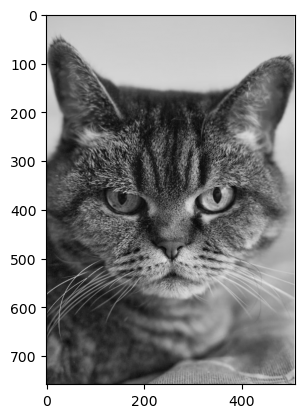

In [7]:
# show the original image
plt.imshow(img, cmap='gray')

In [10]:
# Step 1: Calculate Histogram
histogram = [0] * 256

rows, cols = img.shape

for i in range(rows):
    for j in range(cols):
        pixel = img[i, j]
        histogram[pixel] += 1

In [11]:
# Step 2: Calculate PDF
total_pixels = rows * cols

pdf = [0] * 256

for i in range(256):
    pdf[i] = histogram[i] / total_pixels

In [12]:
# Step 3: Calculate CDF
cdf = [0] * 256

cdf[0] = pdf[0]

for i in range(1, 256):
    cdf[i] = cdf[i - 1] + pdf[i]

In [13]:
# Step 4: Create Mapping
# s = round((L-1) * CDF)
# L = 256
mapping = [0] * 256

for i in range(256):
    mapping[i] = round(255 * cdf[i])

In [15]:
# Step 5: Generate Equalized Image
equalized = np.zeros((rows, cols), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        equalized[i, j] = mapping[img[i, j]]

In [16]:
# Step 6: Histogram of Equalized Image
new_histogram = [0] * 256

for i in range(rows):
    for j in range(cols):
        pixel = equalized[i, j]
        new_histogram[pixel] += 1

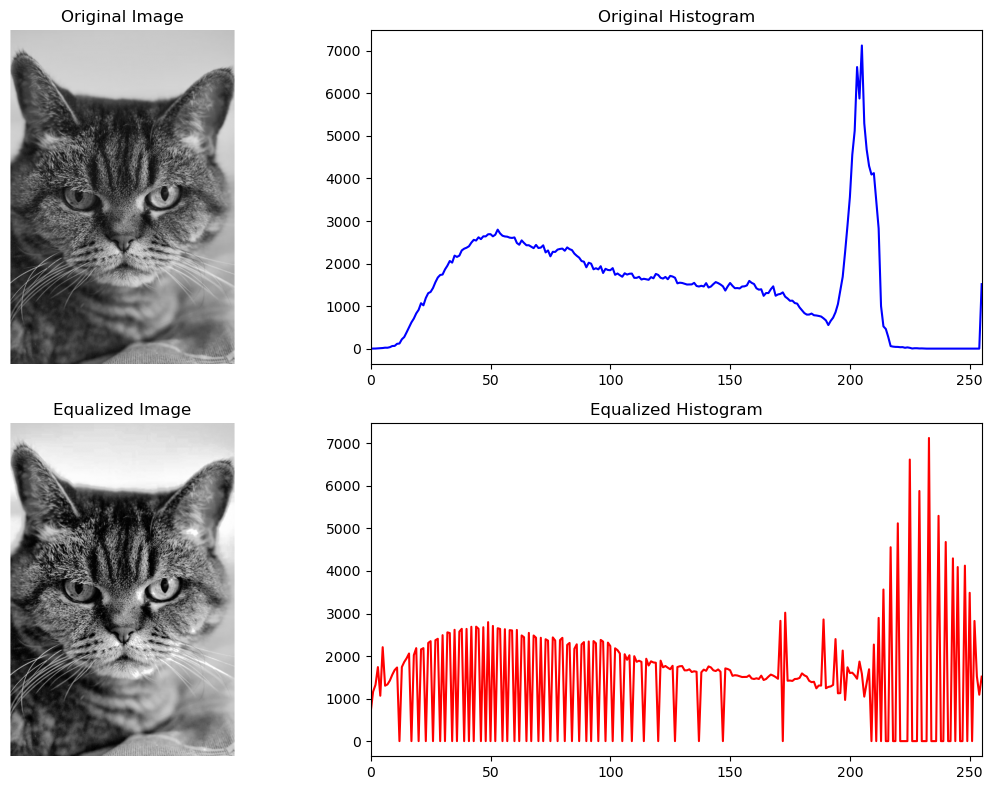

In [20]:
# Display Results
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.plot(histogram, color='blue')
plt.title("Original Histogram")
plt.xlim([0,255])

plt.subplot(2,2,3)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized Image")
plt.axis("off")

plt.subplot(2,2,4)
plt.plot(new_histogram, color='red')
plt.title("Equalized Histogram")
plt.xlim([0,255])

plt.tight_layout()
plt.show()